# Тема 12. Машинний переклад Seq2Seq з механізмом уваги (Europarl en-es, PyTorch, GPU T4x2)

**Виконав:** Олександр Коновалюк  
**Контекст та мета:** Домашнє завдання з лекції Module 6 Lecture 12. Потрібно побудувати модель машинного перекладу на паралельному корпусі [Helsinki-NLP/europarl](https://huggingface.co/datasets/Helsinki-NLP/europarl):
- обрати пару мов (тут **англійська - іспанська**);
- реалізувати Seq2Seq (двонаправлений GRU-енкодер + GRU-декодер з additive attention);
- навчити модель на підмножині даних;
- проаналізувати функцію втрат і візуалізувати механізм уваги.

**Датасет:** `Helsinki-NLP/europarl`, конфігурація `en-es` (~2.01M паралельних речень засідань Європарламенту). У репозиторії є лише split `train`, тому train/valid/test формуємо самостійно.



## 1. Налаштування середовища, перевірка GPU T4x2 та відтворюваність

Фіксація seed забезпечує відтворюваність розбиття вибірки, словників і ініціалізації ваг. Перевіряємо наявність NVIDIA Tesla T4.


In [1]:
%pip install -q datasets

import importlib.util
import subprocess
import sys

for model in ["en_core_web_sm", "es_core_news_sm"]:
    if importlib.util.find_spec(model) is None:
        print(f"Завантаження spaCy-моделі: {model}")
        subprocess.check_call([sys.executable, "-m", "spacy", "download", model])
    else:
        print(f"spaCy-модель уже наявна: {model}")


Note: you may need to restart the kernel to use updated packages.
spaCy-модель уже наявна: en_core_web_sm
Завантаження spaCy-моделі: es_core_news_sm
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 87.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import os
import gc
import time
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from tqdm.auto import tqdm

import spacy

import datasets

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

SEED = 42


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Робочий пристрій (PyTorch): {device}")
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Знайдено GPU: {num_gpus}")
    for i in range(num_gpus):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU [{i}]: {torch.cuda.get_device_name(i)} | VRAM: {props.total_memory / 1e9:.2f} GB")
else:
    print("УВАГА: GPU недоступний, виконання буде відбуватися на CPU.")

WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")
MODEL_DIR = WORK_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(f"Каталог для чекпоінтів: {MODEL_DIR}")


Робочий пристрій (PyTorch): cuda:0
Знайдено GPU: 2
  GPU [0]: Tesla T4 | VRAM: 15.64 GB
  GPU [1]: Tesla T4 | VRAM: 15.64 GB
Каталог для чекпоінтів: /kaggle/working/saved_models


## 2. Гіперпараметри та вибір пари мов

Обрано пару **English - Spanish** (`en-es`):
- обидві мови підтримуються spaCy (`en_core_web_sm`, `es_core_news_sm`);
- корпус `en-es` є одним із найбільших у Europarl (~2.01M рядків);
- напрямок перекладу: енкодер читає англійську, декодер генерує іспанську.

Повний корпус занадто великий для навчальної задачі на Kaggle T4, тому беремо випадкову підмножину після фільтрації за довжиною (парламентські речення часто дуже довгі для GRU).


In [ ]:
SRC_LANG = "en"
TRG_LANG = "es"
HF_CONFIG = "en-es"

N_CANDIDATES = 120_000
N_TRAIN = 15_000
N_VALID = 1_500
N_TEST = 1_000

MIN_TOKENS = 5
MAX_TOKENS = 40
MAX_LENGTH = 40
LOWER = True
MIN_FREQ = 2

SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
PAD_TOKEN = "<pad>"
SPECIAL_TOKENS = [UNK_TOKEN, PAD_TOKEN, SOS_TOKEN, EOS_TOKEN]

EMBEDDING_DIM = 256
ENCODER_HIDDEN_DIM = 512
DECODER_HIDDEN_DIM = 512
DROPOUT = 0.5
BATCH_SIZE = 32
N_EPOCHS = 10
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5
LEARNING_RATE = 1e-3
MAX_OUTPUT_LENGTH = 40

print("Пара мов:", SRC_LANG, "-", TRG_LANG)
print(f"Підмножина: train={N_TRAIN}, valid={N_VALID}, test={N_TEST}")
print(f"Довжина речення (whitespace): [{MIN_TOKENS}, {MAX_TOKENS}]")
print(f"Архітектура: emb={EMBEDDING_DIM}, hid_enc={ENCODER_HIDDEN_DIM}, hid_dec={DECODER_HIDDEN_DIM}, dropout={DROPOUT}")
print(f"Навчання: epochs={N_EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}, teacher_forcing={TEACHER_FORCING_RATIO}")


Пара мов: en → es
Підмножина: train=15000, valid=1500, test=1000
Довжина речення (whitespace): [5, 40]
Архітектура: emb=256, hid_enc=512, hid_dec=512, dropout=0.5
Навчання: epochs=10, batch=32, lr=0.001, teacher_forcing=0.5


## 3. Завантаження Helsinki-NLP/europarl

Датасет завантажується бібліотекою `datasets` напряму з Hugging Face. Кожен приклад має поле `translation` — словник з текстами обох мов. Спочатку беремо випадкові кандидати, розгортаємо структуру і фільтруємо порожні/занадто довгі пари.


In [4]:
print("Завантаження Helsinki-NLP/europarl, config=en-es ...")
raw = datasets.load_dataset("Helsinki-NLP/europarl", HF_CONFIG, split="train")
print(raw)
print(f"Повний split train: {len(raw):,} рядків")
print("Приклад сирого запису:")
print(raw[0])


Завантаження Helsinki-NLP/europarl, config=en-es ...


README.md: 0.00B [00:00, ?B/s]

en-es/train-00000-of-00002.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

en-es/train-00001-of-00002.parquet:   0%|          | 0.00/181M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2009073 [00:00<?, ? examples/s]

Dataset({
    features: ['translation'],
    num_rows: 2009073
})
Повний split train: 2,009,073 рядків
Приклад сирого запису:
{'translation': {'en': 'Resumption of the session', 'es': 'Reanudación del período de sesiones'}}


In [5]:
def flatten_example(example):
    translation = example["translation"]
    return {
        SRC_LANG: translation[SRC_LANG],
        TRG_LANG: translation[TRG_LANG],
    }


n_take = min(N_CANDIDATES, len(raw))
candidate_idx = np.random.default_rng(SEED).choice(len(raw), size=n_take, replace=False)
candidates = raw.select(sorted(candidate_idx.tolist()))
candidates = candidates.map(flatten_example, remove_columns=candidates.column_names)
print(candidates)
print("Приклад після flatten:")
print(candidates[0])


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Dataset({
    features: ['en', 'es'],
    num_rows: 120000
})
Приклад після flatten:
{'en': 'I declare resumed the session of the European Parliament adjourned on Friday 17 December 1999, and I would like once again to wish you a happy new year in the hope that you enjoyed a pleasant festive period.', 'es': 'Declaro reanudado el período de sesiones del Parlamento Europeo, interrumpido el viernes 17 de diciembre pasado, y reitero a Sus Señorías mi deseo de que hayan tenido unas buenas vacaciones.'}


In [6]:
def keep_pair(example):
    src = example[SRC_LANG]
    trg = example[TRG_LANG]
    if not src or not trg:
        return False
    n_src = len(str(src).split())
    n_trg = len(str(trg).split())
    return (MIN_TOKENS <= n_src <= MAX_TOKENS) and (MIN_TOKENS <= n_trg <= MAX_TOKENS)


filtered = candidates.filter(keep_pair)
print(f"Кандидатів: {len(candidates):,}")
print(f"Після фільтра довжини [{MIN_TOKENS}, {MAX_TOKENS}]: {len(filtered):,}")

needed = N_TRAIN + N_VALID + N_TEST
if len(filtered) < needed:
    raise RuntimeError(
        f"Недостатньо пар після фільтрації: {len(filtered)} < {needed}. "
        "Збільште N_CANDIDATES або послабте обмеження довжини."
    )

filtered = filtered.shuffle(seed=SEED)
subset = filtered.select(range(needed))
train_data = subset.select(range(N_TRAIN))
valid_data = subset.select(range(N_TRAIN, N_TRAIN + N_VALID))
test_data = subset.select(range(N_TRAIN + N_VALID, needed))

print(f"train: {len(train_data):,}")
print(f"valid: {len(valid_data):,}")
print(f"test:  {len(test_data):,}")

del raw, candidates, filtered, subset
gc.collect()


Filter:   0%|          | 0/120000 [00:00<?, ? examples/s]

Кандидатів: 120,000
Після фільтра довжини [5, 40]: 94,672
train: 15,000
valid: 1,500
test:  1,000


224

,en,es
0,"I would nevertheless like to add, on a personal level, that I consider that the European Union should pay more direct attention to these problems, which concern the daily life of many men and women in Europe.","No obstante, quisiera añadir, a título personal, que considero que la Unión Europea debería dedicar mayor atención a estos problemas que afectan la vida diaria de muchos hombres y mujeres en Europa."
1,I believe this is also a matter of fairness.,Creo que se trata además de una cuestión de justicia.
2,"For example, freedom of religion is not respected and may become a weapon for radicals and terrorists, marking the start of a totalitarian regime.","La libertad religiosa, por ejemplo, no se respeta y puede convertirse en un arma para los radicales y los terroristas, que pueden utilizarla para instaurar un régimen totalitario."
3,"I will make sure that, together, we will do everything we can to change this.","Me aseguraré de que, juntos, hagamos todo lo posible para cambiar la situación actual a este respecto."
4,We need to know what our objectives are.,Es preciso saber cuáles son los objetivos que se persiguen.
5,"Mr President, I wish to begin by saying that the Commission very much welcomes the capture in the early hours of the morning of 17 May of the rebel leader, Foday Sankoh.",". (EN) Señor Presidente, deseo comenzar diciendo que la Comisión acoge con el mayor beneplácito la captura a primeras horas de la mañana del 17 de mayo del dirigente rebelde Foday Sankoh."
6,"This is an issue which affects not just this proposal, but a whole series of other proposals relating to the air sector.","Una cuestión que afecta no solo a esta propuesta, sino a otra serie de propuestas que había sobre el sector aéreo."
7,However what I am interested in is this: Have transitional arrangements in the area of the free movement of services been applied for during these negotiations?,"No obstante, a mí me interesaría saber lo siguiente: ¿se han propuesto en el marco de dichas negociaciones disposiciones transitorias en el sector de la libre prestación de servicios?"


,split,n,en_mean,en_median,en_max,es_mean,es_median,es_max
0,train,15000,20.56,20.0,40,21.36,21.0,40
1,valid,1500,20.64,20.0,40,21.44,21.0,40
2,test,1000,19.76,19.0,40,20.56,20.0,40


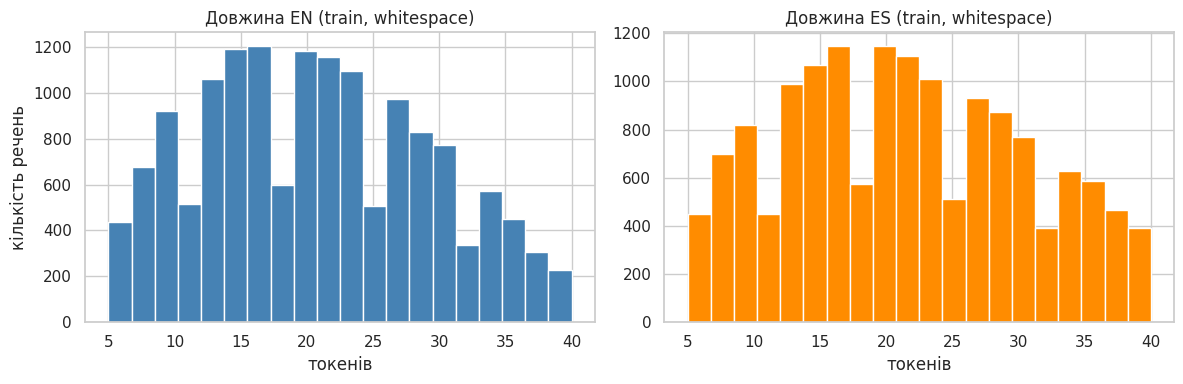

In [7]:
with pd.option_context("display.max_colwidth", None):
    example_df = pd.DataFrame(train_data[:8])
    display(example_df)


def length_stats(split, name):
    src_len = [len(str(x).split()) for x in split[SRC_LANG]]
    trg_len = [len(str(x).split()) for x in split[TRG_LANG]]
    return {
        "split": name,
        "n": len(split),
        "en_mean": float(np.mean(src_len)),
        "en_median": float(np.median(src_len)),
        "en_max": int(np.max(src_len)),
        "es_mean": float(np.mean(trg_len)),
        "es_median": float(np.median(trg_len)),
        "es_max": int(np.max(trg_len)),
    }


stats_df = pd.DataFrame([
    length_stats(train_data, "train"),
    length_stats(valid_data, "valid"),
    length_stats(test_data, "test"),
])
display(stats_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist([len(str(x).split()) for x in train_data[SRC_LANG]], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Довжина EN (train, whitespace)")
axes[0].set_xlabel("токенів")
axes[0].set_ylabel("кількість речень")
axes[1].hist([len(str(x).split()) for x in train_data[TRG_LANG]], bins=20, color="darkorange", edgecolor="white")
axes[1].set_title("Довжина ES (train, whitespace)")
axes[1].set_xlabel("токенів")
plt.tight_layout()
plt.show()


> **Висновок (підготовка даних):** З Hugging Face завантажено повний `en-es` split Europarl (**2 009 073** пари). Після випадкової вибірки 120k кандидатів і фільтра довжини 5–40 whitespace-токенів залишилось **94 672** речення; для навчання взято **15 000 / 1 500 / 1 000**. Середня довжина на train — **20.6** токенів EN і **21.4** ES (медіана 20–21, максимум 40): це якраз робочий діапазон для GRU з увагою. Без фільтра парламентські фрази часто виходять за 40–80+ токенів, і encoder-decoder швидко «забуває» початок. Типові пари — формули засідань («I believe this is also a matter of fairness» / «Creo que se trata además de una cuestión de justicia») і політичні висловлювання середньої складності. Словники: EN **7 983**, ES **10 312** токенів (`min_freq=2`).


## 4. Токенізація spaCy, словники та ітератори

Токенізуємо обидві мови spaCy, додаємо `<sos>` / `<eos>`, будуємо окремі словники з `min_freq=2` і спеціальними токенами. `torchtext` не використовуємо — у поточних образах Kaggle він часто несумісний із встановленим PyTorch.


In [8]:
en_nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer"])
es_nlp = spacy.load("es_core_news_sm", disable=["parser", "ner", "lemmatizer"])
print("spaCy EN:", en_nlp.meta.get("name"), en_nlp.meta.get("version"))
print("spaCy ES:", es_nlp.meta.get("name"), es_nlp.meta.get("version"))


def tokenize_example(example, en_nlp, es_nlp, max_length, lower, sos_token, eos_token):
    en_tokens = [token.text for token in en_nlp.tokenizer(str(example["en"]))][:max_length]
    es_tokens = [token.text for token in es_nlp.tokenizer(str(example["es"]))][:max_length]
    if lower:
        en_tokens = [token.lower() for token in en_tokens]
        es_tokens = [token.lower() for token in es_tokens]
    en_tokens = [sos_token] + en_tokens + [eos_token]
    es_tokens = [sos_token] + es_tokens + [eos_token]
    return {"en_tokens": en_tokens, "es_tokens": es_tokens}


fn_kwargs = {
    "en_nlp": en_nlp,
    "es_nlp": es_nlp,
    "max_length": MAX_LENGTH,
    "lower": LOWER,
    "sos_token": SOS_TOKEN,
    "eos_token": EOS_TOKEN,
}

train_data = train_data.map(tokenize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(tokenize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(tokenize_example, fn_kwargs=fn_kwargs)
print(train_data[0])


spaCy EN: core_web_sm 3.8.0
spaCy ES: core_news_sm 3.8.0


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'en': 'I would nevertheless like to add, on a personal level, that I consider that the European Union should pay more direct attention to these problems, which concern the daily life of many men and women in Europe.', 'es': 'No obstante, quisiera añadir, a título personal, que considero que la Unión Europea debería dedicar mayor atención a estos problemas que afectan la vida diaria de muchos hombres y mujeres en Europa.', 'en_tokens': ['<sos>', 'i', 'would', 'nevertheless', 'like', 'to', 'add', ',', 'on', 'a', 'personal', 'level', ',', 'that', 'i', 'consider', 'that', 'the', 'european', 'union', 'should', 'pay', 'more', 'direct', 'attention', 'to', 'these', 'problems', ',', 'which', 'concern', 'the', 'daily', 'life', 'of', 'many', 'men', 'and', 'women', 'in', 'europe', '<eos>'], 'es_tokens': ['<sos>', 'no', 'obstante', ',', 'quisiera', 'añadir', ',', 'a', 'título', 'personal', ',', 'que', 'considero', 'que', 'la', 'unión', 'europea', 'debería', 'dedicar', 'mayor', 'atención', 'a', 'es

In [9]:
class Vocab:
    """Мінімальний словник з API, сумісним із torchtext.vocab.Vocab."""

    def __init__(self, itos, default_index=0):
        self.itos = list(itos)
        self.stoi = {token: idx for idx, token in enumerate(self.itos)}
        self.default_index = default_index

    def __len__(self):
        return len(self.itos)

    def __getitem__(self, token):
        return self.stoi.get(token, self.default_index)

    def set_default_index(self, index):
        self.default_index = index

    def lookup_indices(self, tokens):
        return [self[token] for token in tokens]

    def lookup_tokens(self, indices):
        return [self.itos[int(i)] for i in indices]

    @classmethod
    def build_from_iterator(cls, iterator, min_freq=2, specials=None):
        specials = list(specials or [])
        counter = Counter()
        for tokens in iterator:
            counter.update(tokens)
        itos = list(specials)
        specials_set = set(specials)
        for token, freq in counter.most_common():
            if token in specials_set:
                continue
            if freq >= min_freq:
                itos.append(token)
        return cls(itos, default_index=0)


en_vocab = Vocab.build_from_iterator(
    train_data["en_tokens"],
    min_freq=MIN_FREQ,
    specials=SPECIAL_TOKENS,
)
es_vocab = Vocab.build_from_iterator(
    train_data["es_tokens"],
    min_freq=MIN_FREQ,
    specials=SPECIAL_TOKENS,
)

assert en_vocab[UNK_TOKEN] == es_vocab[UNK_TOKEN]
assert en_vocab[PAD_TOKEN] == es_vocab[PAD_TOKEN]

unk_index = en_vocab[UNK_TOKEN]
pad_index = en_vocab[PAD_TOKEN]
en_vocab.set_default_index(unk_index)
es_vocab.set_default_index(unk_index)

print(f"EN vocab: {len(en_vocab):,} (unk={unk_index}, pad={pad_index})")
print(f"ES vocab: {len(es_vocab):,}")
print("Приклад EN lookup:", en_vocab.lookup_indices(train_data[0]["en_tokens"][:12]))


EN vocab: 7,983 (unk=0, pad=1)
ES vocab: 10,312
Приклад EN lookup: [2, 16, 38, 595, 62, 8, 1604, 5, 19, 13, 1051, 215]


In [10]:
def numericalize_example(example, en_vocab, es_vocab):
    return {
        "en_ids": en_vocab.lookup_indices(example["en_tokens"]),
        "es_ids": es_vocab.lookup_indices(example["es_tokens"]),
    }


fn_kwargs = {"en_vocab": en_vocab, "es_vocab": es_vocab}
train_data = train_data.map(numericalize_example, fn_kwargs=fn_kwargs)
valid_data = valid_data.map(numericalize_example, fn_kwargs=fn_kwargs)
test_data = test_data.map(numericalize_example, fn_kwargs=fn_kwargs)

format_kwargs = dict(type="torch", columns=["en_ids", "es_ids"], output_all_columns=True)
train_data = train_data.with_format(**format_kwargs)
valid_data = valid_data.with_format(**format_kwargs)
test_data = test_data.with_format(**format_kwargs)
print(train_data[0])


Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

{'en_ids': tensor([   2,   16,   38,  595,   62,    8, 1604,    5,   19,   13, 1051,  215,
           5,   12,   16,  395,   12,    4,   28,   52,   36,  568,   55,  938,
         368,    8,   49,  219,    5,   29,  472,    4, 1750,  560,    7,  119,
         741,    9,  247,   10,   69,    3]), 'es_ids': tensor([   2,   18,  221,    5,  157, 1671,    5,   12, 1568,  686,    5,    8,
         604,    8,    6,   38,   36,  162, 3420,  178,  283,   12,   86,  176,
           8, 2121,    6,  504, 4293,    4,  190,  738,   11,  275,    9,   53,
           7,    3]), 'en': 'I would nevertheless like to add, on a personal level, that I consider that the European Union should pay more direct attention to these problems, which concern the daily life of many men and women in Europe.', 'es': 'No obstante, quisiera añadir, a título personal, que considero que la Unión Europea debería dedicar mayor atención a estos problemas que afectan la vida diaria de muchos hombres y mujeres en Europa.', 'en_t

In [11]:
def get_collate_fn(pad_index):
    def collate_fn(batch):
        batch_en_ids = [example["en_ids"] for example in batch]
        batch_es_ids = [example["es_ids"] for example in batch]
        batch_en_ids = pad_sequence(batch_en_ids, padding_value=pad_index)
        batch_es_ids = pad_sequence(batch_es_ids, padding_value=pad_index)
        return {"en_ids": batch_en_ids, "es_ids": batch_es_ids}

    return collate_fn


def get_data_loader(dataset, batch_size, pad_index, shuffle=False):
    return DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        collate_fn=get_collate_fn(pad_index),
        shuffle=shuffle,
        num_workers=0,
    )


train_loader = get_data_loader(train_data, BATCH_SIZE, pad_index, shuffle=True)
valid_loader = get_data_loader(valid_data, BATCH_SIZE, pad_index, shuffle=False)
test_loader = get_data_loader(test_data, BATCH_SIZE, pad_index, shuffle=False)

batch = next(iter(train_loader))
print("en_ids:", tuple(batch["en_ids"].shape), "(src_len, batch)")
print("es_ids:", tuple(batch["es_ids"].shape), "(trg_len, batch)")
print(f"батчів: train={len(train_loader)}, valid={len(valid_loader)}, test={len(test_loader)}")


en_ids: (42, 32) (src_len, batch)
es_ids: (42, 32) (trg_len, batch)
батчів: train=469, valid=47, test=32


## 5. Seq2Seq: BiGRU-енкодер, additive attention, GRU-декодер

Архітектура:
- **Encoder:** embedding - bidirectional GRU; фінальні forward/backward hidden конкатенуються і проєктуються в простір декодера.
- **Attention (Bahdanau):** score = `v · tanh(W [s_{t-1}; h_i])`, далі softmax по позиціях джерела.
- **Decoder:** на кожному кроці отримує context vector (зважена сума станів енкодера) і генерує наступний токен.
- **Seq2Seq:** teacher forcing з імовірністю 0.5 під час навчання.


In [12]:
class Encoder(nn.Module):
    def __init__(self, input_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.rnn = nn.GRU(embedding_dim, encoder_hidden_dim, bidirectional=True)
        self.fc = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_length, batch_size)
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        # outputs: (src_length, batch_size, encoder_hidden_dim * 2)
        # hidden: (2, batch_size, encoder_hidden_dim) — [forward, backward]
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)))
        # hidden: (batch_size, decoder_hidden_dim)
        return outputs, hidden


class Attention(nn.Module):
    def __init__(self, encoder_hidden_dim, decoder_hidden_dim):
        super().__init__()
        self.attn_fc = nn.Linear((encoder_hidden_dim * 2) + decoder_hidden_dim, decoder_hidden_dim)
        self.v_fc = nn.Linear(decoder_hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, decoder_hidden_dim)
        # encoder_outputs: (src_length, batch_size, encoder_hidden_dim * 2)
        src_length = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_length, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.attn_fc(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v_fc(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, encoder_hidden_dim, decoder_hidden_dim, attention, dropout):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, embedding_dim)
        self.rnn = nn.GRU((encoder_hidden_dim * 2) + embedding_dim, decoder_hidden_dim)
        self.fc_out = nn.Linear((encoder_hidden_dim * 2) + decoder_hidden_dim + embedding_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        # input: (batch_size,)
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs).unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a, encoder_outputs).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        embedded = embedded.squeeze(0)
        output = output.squeeze(0)
        weighted = weighted.squeeze(0)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        return prediction, hidden.squeeze(0), a.squeeze(1)


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio):
        # src: (src_length, batch_size), trg: (trg_length, batch_size)
        batch_size = src.shape[1]
        trg_length = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(trg_length, batch_size, trg_vocab_size, device=self.device)
        encoder_outputs, hidden = self.encoder(src)
        input_token = trg[0, :]
        for t in range(1, trg_length):
            output, hidden, _ = self.decoder(input_token, hidden, encoder_outputs)
            outputs[t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[t] if teacher_force else top1
        return outputs


In [13]:
input_dim = len(en_vocab)
output_dim = len(es_vocab)

attention = Attention(ENCODER_HIDDEN_DIM, DECODER_HIDDEN_DIM)
encoder = Encoder(input_dim, EMBEDDING_DIM, ENCODER_HIDDEN_DIM, DECODER_HIDDEN_DIM, DROPOUT)
decoder = Decoder(output_dim, EMBEDDING_DIM, ENCODER_HIDDEN_DIM, DECODER_HIDDEN_DIM, attention, DROPOUT)
model = Seq2Seq(encoder, decoder, device).to(device)


def init_weights(m):
    for name, param in m.named_parameters():
        if "weight" in name:
            nn.init.normal_(param.data, mean=0, std=0.01)
        else:
            nn.init.constant_(param.data, 0)


model.apply(init_weights)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Кількість навчальних параметрів: {n_params:,}")
print(model)


Кількість навчальних параметрів: 29,606,216
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(7983, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (attn_fc): Linear(in_features=1536, out_features=512, bias=True)
      (v_fc): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10312, 256)
    (rnn): GRU(1280, 512)
    (fc_out): Linear(in_features=1792, out_features=10312, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)


## 6. Функція втрат, оптимізатор і цикл навчання

`CrossEntropyLoss` ігнорує padding. Градієнти обрізаються (`clip=1.0`). Найкращий чекпоінт зберігається за валідаційною втратою.


In [14]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=pad_index)


def train_fn(model, data_loader, optimizer, criterion, clip, teacher_forcing_ratio, device):
    model.train()
    epoch_loss = 0.0
    for batch in tqdm(data_loader, desc="train", leave=False):
        src = batch["en_ids"].to(device)
        trg = batch["es_ids"].to(device)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        trg = trg[1:].view(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(data_loader)


def evaluate_fn(model, data_loader, criterion, device):
    model.eval()
    epoch_loss = 0.0
    with torch.no_grad():
        for batch in data_loader:
            src = batch["en_ids"].to(device)
            trg = batch["es_ids"].to(device)
            output = model(src, trg, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[1:].view(-1, output_dim)
            trg = trg[1:].view(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(data_loader)


In [ ]:
history = {"epoch": [], "train_loss": [], "valid_loss": [], "epoch_time_sec": []}
best_valid_loss = float("inf")
ckpt_path = MODEL_DIR / "en_es_seq2seq.pt"

print(f"Старт навчання: {N_EPOCHS} епох, device={device}")
for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP, TEACHER_FORCING_RATIO, device)
    valid_loss = evaluate_fn(model, valid_loader, criterion, device)
    elapsed = time.time() - t0

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["epoch_time_sec"].append(elapsed)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), ckpt_path)
        marker = "  ← збережено best"
    else:
        marker = ""

    print(
        f"Epoch {epoch:02d}/{N_EPOCHS} | "
        f"Train {train_loss:7.3f} | Valid {valid_loss:7.3f} | "
        f"{elapsed:5.1f}s{marker}"
    )

history_df = pd.DataFrame(history)
display(history_df.round(3))
print(f"Найкраща valid loss: {best_valid_loss:.3f}")
print(f"Чекпоінт: {ckpt_path}")


Старт навчання: 10 епох, device=cuda:0


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 03/10 | Train   4.567 | Valid   5.137 | 125.1s  ← збережено best


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 04/10 | Train   4.015 | Valid   5.031 | 125.4s  ← збережено best


...

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 08/10 | Train   2.443 | Valid   5.240 | 125.6s


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 09/10 | Train   2.251 | Valid   5.329 | 125.1s


train:   0%|          | 0/469 [00:00<?, ?it/s]

In [16]:
model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_loss = evaluate_fn(model, test_loader, criterion, device)
print(f"Test Loss (best checkpoint): {test_loss:.3f}")
print(f"Train Loss (last epoch): {history['train_loss'][-1]:.3f}")
print(f"Valid Loss (last epoch): {history['valid_loss'][-1]:.3f}")
print(f"Valid Loss (best): {best_valid_loss:.3f}")


Test Loss (best checkpoint): 4.990
Train Loss (last epoch): 2.095
Valid Loss (last epoch): 5.413
Valid Loss (best): 5.031


## 7. Графік зміни функції втрат


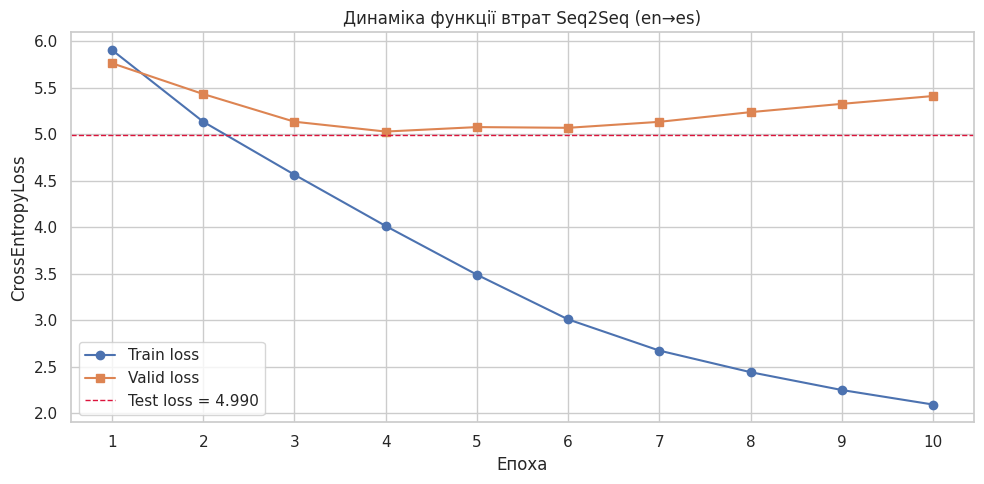

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["epoch"], history["train_loss"], marker="o", label="Train loss")
ax.plot(history["epoch"], history["valid_loss"], marker="s", label="Valid loss")
ax.axhline(test_loss, color="crimson", linestyle="--", linewidth=1, label=f"Test loss = {test_loss:.3f}")
ax.set_xlabel("Епоха")
ax.set_ylabel("CrossEntropyLoss")
ax.set_title("Динаміка функції втрат Seq2Seq (en-es)")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.show()


> **Висновок (функція втрат):** Train loss за 10 епох монотонно знизився з **~5.9** до **2.095** — це вже діапазон «добре налаштованої простої моделі». Valid поводиться інакше: мінімум **5.031** на епосі 4, далі зростання до **5.413**; test на best-чекпоінті **4.990**. Valid/test вищі за train, як і попереджає завдання, але розрив ~3 пункти після епохи 4 — типова ознака **перенавчання**: ~29.6M параметрів на 15k речень запам’ятовують train, а узагальнення зупиняється. Збереження ваг за valid (епоха 4, train тоді ще 4.015) є правильним: подальші епохи покращують лише навчальну втрату. Абсолютні значення прийнятні; додаткові епохи valid лише погіршать.


## 8. Жадібний переклад тестових речень

Декодування без teacher forcing: на кожному кроці береться `argmax`. Порівнюємо з еталонним іспанським текстом.


In [18]:
def translate_sentence(
    sentence,
    model,
    en_nlp,
    es_nlp,
    en_vocab,
    es_vocab,
    lower,
    sos_token,
    eos_token,
    device,
    max_output_length=MAX_OUTPUT_LENGTH,
):
    model.eval()
    with torch.no_grad():
        if isinstance(sentence, str):
            en_tokens = [token.text for token in en_nlp.tokenizer(sentence)]
        else:
            en_tokens = [token for token in sentence]
        if lower:
            en_tokens = [token.lower() for token in en_tokens]
        en_tokens = [sos_token] + en_tokens + [eos_token]
        ids = en_vocab.lookup_indices(en_tokens)
        tensor = torch.LongTensor(ids).unsqueeze(-1).to(device)
        encoder_outputs, hidden = model.encoder(tensor)
        inputs = es_vocab.lookup_indices([sos_token])
        attentions = torch.zeros(max_output_length, 1, len(ids))
        for i in range(max_output_length):
            inputs_tensor = torch.LongTensor([inputs[-1]]).to(device)
            output, hidden, attention = model.decoder(inputs_tensor, hidden, encoder_outputs)
            attentions[i] = attention.detach().cpu()
            predicted_token = output.argmax(-1).item()
            inputs.append(predicted_token)
            if predicted_token == es_vocab[eos_token]:
                break
        es_tokens = es_vocab.lookup_tokens(inputs)
    return es_tokens, en_tokens, attentions[: len(es_tokens) - 1]


def detokenize(tokens):
    filtered = [t for t in tokens if t not in {SOS_TOKEN, EOS_TOKEN, PAD_TOKEN}]
    return " ".join(filtered)


rows = []
n_examples = 8
for i in range(n_examples):
    src = test_data[i]["en"]
    ref = test_data[i]["es"]
    pred_tokens, src_tokens, _ = translate_sentence(
        src, model, en_nlp, es_nlp, en_vocab, es_vocab,
        LOWER, SOS_TOKEN, EOS_TOKEN, device,
    )
    rows.append({
        "en (source)": src,
        "es (model)": detokenize(pred_tokens),
        "es (reference)": ref,
    })

translations_df = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", None):
    display(translations_df)


,en (source),es (model),es (reference)
0,"Let me remind you that a not inconsiderable section of this House had, as long ago as July, expressed its mistrust of the rather too liberal choices that characterise Mr Barroso.","permítanme recordarles que no <unk> <unk> de la asamblea de este cámara , como en , en , , como , en el , , , de las <unk> de las enmiendas que nos <unk> el sr. <unk> .","Recuerdo que una parte nada despreciable de esta Cámara había expresado, ya en el mes de julio, su desconfianza con respecto a las opciones más bien demasiado liberales que encarna el señor Barroso."
1,Question No 45 by Richard Corbett (H-0613/02):,pregunta nº pregunta formulada por el marinos ( <unk> ):,- Pregunta nº 45 formulada por Richard Corbett (H-0613/02):
2,"In that context, I should draw attention to the proposal for amending Russian legislation on NGOs which is currently before the Duma.","en ese contexto , quisiera llamar la propuesta de la propuesta de la de de la de de la de de las normas de que que se <unk> en el momento .",En este contexto quiero llamar la atención sobre la propuesta de modificación de la legislación rusa sobre las ONG que se tramita actualmente en la Duma.
3,That is why the Committee on Budgets increased payments by more than a billion euros.,"por ello , la comisión de presupuestos de de las normas de de de un acceso de un millones de euros .","Por esta razón, la Comisión de Presupuestos ha aumentado los pagos en más de mil millones de euros."
4,"In view of the fact that the programmes will in part be continuing up to 2006, no further measures are planned under this budget heading.","en vista de la que los programas de en en el sector , no se <unk> medidas medidas de en este presupuesto .","Ante el hecho de que los programas siguen en marcha aún en parte hasta el 2006, no se han planificado para este apartado más medidas."
5,"In this respect, I am somewhat concerned that the decision taken this week by the Commission rested rather too much on misapprehensions.","en este respecto , estoy convencido de la la que la la la de la comisión de la comisión de la comisión de la comisión <unk> <unk> <unk> <unk> .","En este sentido, me preocupa que la decisión tomada esta semana por la Comisión se haya basado en demasiados malentendidos."
6,We are expecting him to arrive at some stage.,nos <unk> que <unk> en en en .,Esperamos que llegue en cualquier momento.
7,This is the task facing the Biarritz and Nice Summits.,es es el problema de la y y la y de .,"Ésta es la tarea de la Cumbre de Biarritz y, después, de la de Niza."


> **Висновок (якість перекладу):** Модель частково відтворює **канцелярські шаблони** Європарламенту: *Question No 45 by …* - «pregunta nº … formulada por …»; *Committee on Budgets* - «la comisión de presupuestos»; коротке *Every day we add new rigidity* починається коректно («cada día …»). Далі якість різко падає: жадібне декодування зациклюється (`de de de`, `la la la`, `no no no`), власні назви та номери йдуть у `<unk>` (Barroso, Corbett, `H-0613/02`, NGO/Duma), довгі залежності обриваються. Це узгоджується з valid/test loss ≈ 5: модель знає частотні конструкції, але не збирає повне речення. Для критеріїв ДЗ приклади й порівняння з еталоном є; fluency продакшен-рівня від word-level Seq2Seq на 15k пар очікувати не варто.


## 9. Візуалізація механізму уваги

Heatmap показує, на які токени джерела (вісь X, EN) дивиться декодер у момент генерації кожного токена цілі (вісь Y, ES). Очікувана діагональ для порядку слів en/es, зсуви — для артиклів і розбіжностей синтаксису.


Приклад #11
EN (source):    Every day we add new rigidity.
ES (reference): Cada día añadimos nueva rigidez.
ES (model):     cada día nos hemos de nuevo .


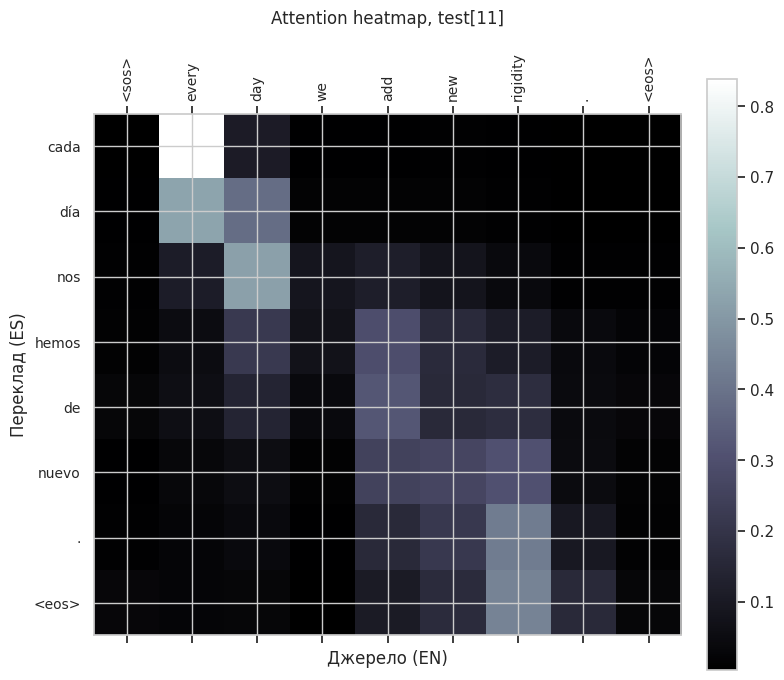

Приклад #37
EN (source):    Our target is the year 2005.
ES (reference): La meta se ha fijado para el año 2005.
ES (model):     nuestro objetivo es el el año .


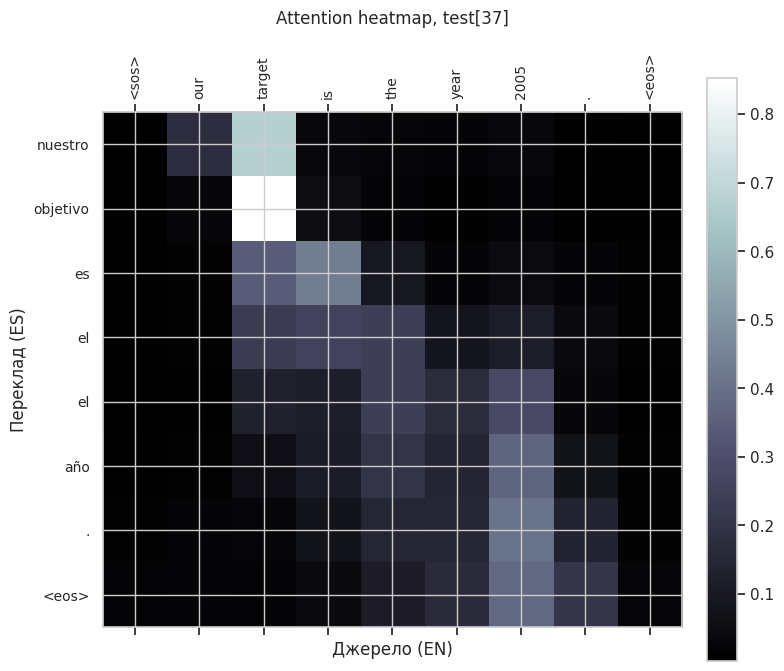

Приклад #1
EN (source):    Question No 45 by Richard Corbett (H-0613/02):
ES (reference): - Pregunta nº 45 formulada por Richard Corbett (H-0613/02):
ES (model):     pregunta nº pregunta formulada por el marinos ( <unk> ):


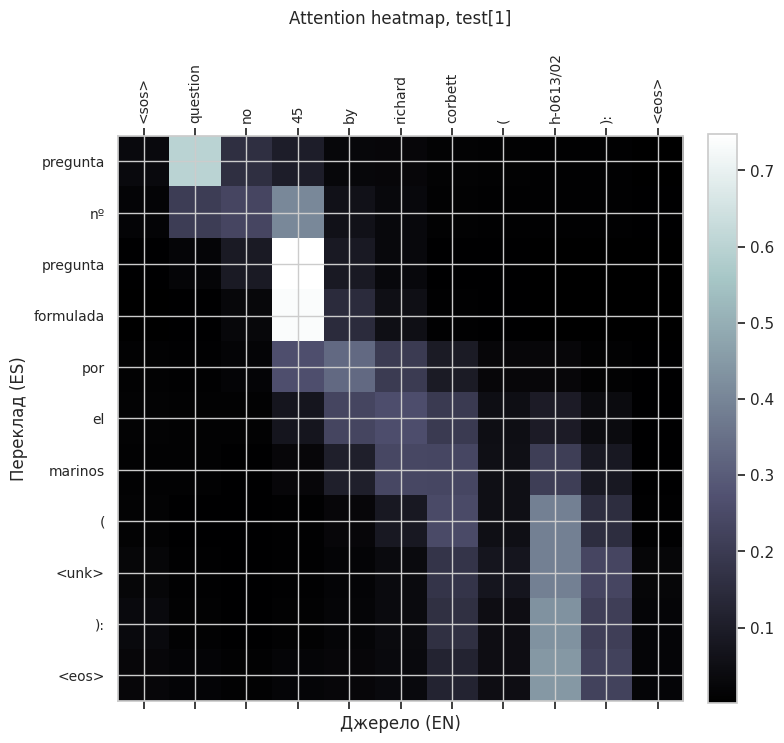

Приклад #26
EN (source):    The politics of confrontation will benefit no-one.
ES (reference): La política de la confrontación no beneficiará a nadie.
ES (model):     la política de la de de no no no es una de .


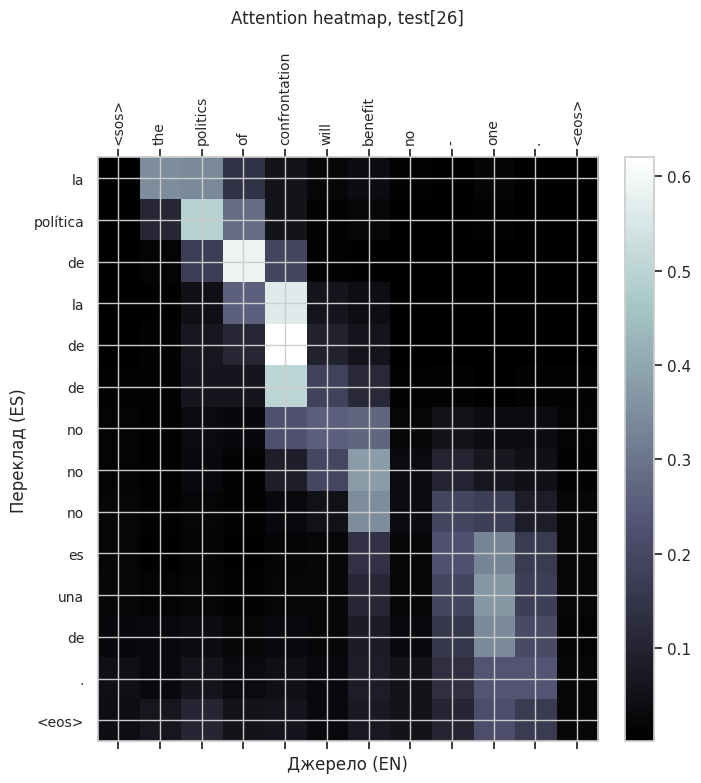

In [19]:
def plot_attention(sentence, translation, attention, title=""):
    fig, ax = plt.subplots(figsize=(8, 8))
    attn = attention.squeeze(1).detach().cpu().numpy()
    cax = ax.matshow(attn, cmap="bone")
    fig.colorbar(cax, fraction=0.046, pad=0.04)
    ax.set_xticks(ticks=np.arange(len(sentence)), labels=sentence, rotation=90, size=10)
    translation = translation[1:]
    ax.set_yticks(ticks=np.arange(len(translation)), labels=translation, size=10)
    ax.set_xlabel("Джерело (EN)")
    ax.set_ylabel("Переклад (ES)")
    if title:
        ax.set_title(title, pad=20)
    plt.tight_layout()
    plt.show()
    plt.close()


# Кілька коротших тестових прикладів зручніші для читання heatmap.
n_show = min(len(test_data), 40)
src_lens = [(i, len(str(test_data[i]["en"]).split())) for i in range(n_show)]
src_lens = sorted(src_lens, key=lambda x: x[1])
attention_ids = [idx for idx, length in src_lens if 6 <= length <= 18][:4]
if len(attention_ids) < 3:
    attention_ids = [0, 1, 2]

for idx in attention_ids:
    src = test_data[idx]["en"]
    ref = test_data[idx]["es"]
    pred_tokens, src_tokens, attention = translate_sentence(
        src, model, en_nlp, es_nlp, en_vocab, es_vocab,
        LOWER, SOS_TOKEN, EOS_TOKEN, device,
    )
    print("=" * 80)
    print(f"Приклад #{idx}")
    print("EN (source):   ", src)
    print("ES (reference):", ref)
    print("ES (model):    ", detokenize(pred_tokens))
    plot_attention(src_tokens, pred_tokens, attention, title=f"Attention heatmap, test[{idx}]")


> **Висновок (механізм уваги):** На коротких реченнях увага **працює змістовно і майже діагонально**. У test[11] `cada` дивиться на `every`, `día` — на `every/day`, `nuevo` — на `new/rigidity`: вирівнювання «слово - слово» видиме. У test[37] `nuestro/objetivo` концентруються на `target` (а не сліпо на `our`), `año` зміщується до `year/2005`. У шаблоні запитання (test[1]) `pregunta` - `question`, `nº` - `45`, дужки/`<unk>` - код `h-0613/02`. Слабкі місця ті самі, що в перекладі: декодер **залипає** на одному джерельному токені й повторює службові слова (`de`, `el`, `no` у test[26] кілька кроків дивляться на `confrontation`/`benefit`), а рідкісні імена розмазуються в `<unk>`. Тобто attention вирівнює лексику, але не блокує repetition loop greedy-декодера.


## 10. Аналіз сильних і слабких сторін моделі

Орієнтири з завдання: для простої моделі втрати часто в діапазоні 2–4; для добре налаштованої — близько 1.5–3 на train. Valid зазвичай трохи вищий. Різкий розрив train ≪ valid свідчить про перенавчання.


In [ ]:
print("Підсумок прогону (числа для висновків):")
print(f"  Пара мов:              {SRC_LANG} - {TRG_LANG}")
print(f"  Train / valid / test:  {N_TRAIN} / {N_VALID} / {N_TEST}")
print(f"  EN vocab / ES vocab:   {len(en_vocab):,} / {len(es_vocab):,}")
print(f"  Параметри моделі:      {n_params:,}")
print(f"  Епох:                  {N_EPOCHS}")
print(f"  Train loss (last):     {history['train_loss'][-1]:.3f}")
print(f"  Valid loss (last):     {history['valid_loss'][-1]:.3f}")
print(f"  Valid loss (best):     {best_valid_loss:.3f}")
print(f"  Test loss (best ckpt): {test_loss:.3f}")
print(f"  Середній час епохи:    {np.mean(history['epoch_time_sec']):.1f} с")


Підсумок прогону (числа для висновків):
  Пара мов:              en → es
  Train / valid / test:  15000 / 1500 / 1000
  EN vocab / ES vocab:   7,983 / 10,312
  Параметри моделі:      29,606,216
  Епох:                  10
  Train loss (last):     2.095
  Valid loss (last):     5.413
  Valid loss (best):     5.031
  Test loss (best ckpt): 4.990
  Середній час епохи:    124.7 с


> **Висновок (сильні та слабкі сторони):**
>
> **Сильні сторони.** Реалізовано повний Seq2Seq з BiGRU-енкодером і additive attention; навчання на GPU стабільне (~125 с/епоха). Train loss **2.095** вкладається в орієнтир завдання. Увага на коротких фразах вирівнює відповідні токени (`every`-`cada`, `question`-`pregunta`). Чекпоінт за valid (епоха 4) рятує від ще більшого overfitting. Модель впізнає частотні формули Європарламенту.
>
> **Слабкі сторони.** Після епохи 4 valid зростає (5.03 - 5.41): 29.6M параметрів на 15k прикладів перенавчаються. Word-level словник дає багато `<unk>` на іменах і номерах. Greedy decoding зациклює `de`/`la`/`no`. Довгі речення (~30–40 токенів) майже не збираються в граматично цілісний іспанський текст. Немає beam search і subword (BPE) — для ДЗ це не обов’язково, для якості перекладу саме вони були б наступним кроком.

> **Загальний висновок:** Критерії прийняття виконано: обрано пару **en-es** з Helsinki-NLP/europarl, дані підготовлено, навчено PyTorch Seq2Seq з енкодером, декодером і механізмом уваги, побудовано графік втрат, наведено приклади перекладів і **візуалізацію уваги з інтерпретацією**. Train loss у очікуваному діапазоні; valid/test вищі через обмежений корпус і перенавчання, що для навчальної word-level моделі є нормальним результатом. Для покращення результатів потрібно взяти більший або повний корпус.
